In [2]:
%reload_ext autoreload
%pylab inline
%autoreload 2
import numpy as np
from os.path import join, basename, dirname
import sys
sys.path.insert(0, '/home/did/RTC/SMART-G/smartg/tools/')
from luts import LUT, MLUT, Idx, merge, plot_polar, read_mlut
from smacg import Smacg, get_smac_coeffs
import xarray
from datetime import datetime
from glob import glob

Populating the interactive namespace from numpy and matplotlib


# DEM Read (once!)

In [54]:
# path to DEM
fdem = '/rfs/data/DEM/GTOPO30_MLUT.nc'
dem_lut = read_mlut(fdem) # global DEM GTOPO 30, reading once, could be long, stored into a MLUT object

In [4]:
# dem object is a MLUT object
dem_lut.describe()

 Datasets:
  [0] elev (uint16 in [0, 6.55e+04]), axes=('lat', 'lon')
 Axes:
  [0] lat: 21600 values in [90.0, -90.0]
  [1] lon: 43200 values in [-180.0, 180.0]


# SMACG configuration

In [64]:
# path to input AVHRR image (format netcdf4)
fname = '/rfs/data/AVHRR/1996/199601/C3S-L1B-AVHRR_NOAA-19960101100544-fv0001.nc/testdata_ATHENS-NOA.nc'

year  = basename(dirname(fname))[19:23]
date  = basename(dirname(fname))[19:27]
 
# path to input ancillary MERRA 2 data
# 1) aerosols
#merra_aerosol='/rfs/data/MERRA2/aer_extinction/'+year+'/MERRA2_300.tavg1_2d_aer_Nx.'+date+'.SUB.nc4'
merra_aerosol='/rfs/data/MERRA2/aer_extinction/'+year+'/MERRA2_*.tavg1_2d_aer_Nx.'+date+'.SUB.nc4'
merra_aerosol = glob(merra_aerosol)
if len(merra_aerosol) != 1:
    raise Exception("error on filename merra aerosol")
merra_aerosol = merra_aerosol[0]

# 2) ozone
#merra_ozone='/rfs/data/MERRA2/ozone/'+year+'/MERRA2_300.tavg1_2d_chm_Nx.'+date+'.SUB.nc4'
merra_ozone='/rfs/data/MERRA2/ozone/'+year+'/MERRA2_*.tavg1_2d_chm_Nx.'+date+'.SUB.nc4'
merra_ozone = glob(merra_ozone)
if len(merra_ozone) != 1:
    raise Exception('error on filename merra ozone')
merra_ozone = merra_ozone[0]

# 3) pressure
#merra_pressure='/rfs/data/MERRA2/surf_pression/'+year+'/MERRA2_300.tavg1_2d_slv_Nx.'+date+'.SUB.nc4'
merra_pressure='/rfs/data/MERRA2/surf_pression/'+year+'/MERRA2_*.tavg1_2d_slv_Nx.'+date+'.SUB.nc4'
merra_pressure = glob(merra_pressure)
if len(merra_pressure) != 1:
    raise Exception('error on filename merra pressure')
merra_pressure = merra_pressure[0]

# 4) water vapour
#merra_water='/rfs/data/MERRA2/total_precipitable_water_vapor/'+year+'/MERRA2_300.inst1_2d_int_Nx.'+date+'.SUB.nc4'
merra_water='/rfs/data/MERRA2/total_precipitable_water_vapor/'+year+'/MERRA2_*.inst1_2d_int_Nx.'+date+'.SUB.nc4'
merra_water = glob(merra_water)
if len(merra_water) != 1:
    raise('error on filename merra water')
merra_water = merra_water[0]

# VGT IMAGE SIZE
XSIZE = 49
YSIZE = 49
# VGT TIE POINTS SIZE
XTIE  = 7
YTIE  = 7

# GPU grid
XBLOCK = XSIZE
XGRID  = YSIZE
YGRID  = 1
YBLOCK = 1

M = XBLOCK * XGRID  # elemnentary size of pixel's array : match the GPU grid
Z      = 1 # eventually size of third dimension in the card
NBLOOP = 1 # eventually loops within card (for first version of smacg NLOOP=1)

sensor   = 'NOAA14'  # Effective sensor
aer_coef = 'CONT'  # 'CONT' or 'DES' SMAC aerosol coefficient
tab_band = ['ch1', 'ch2']  # List bands here
tab_band_coef = {'ch1':'VIS', 'ch2':'NIR'}
NB = len(tab_band)  # number of bands
dir_coef_name = './' # directory containing SMAC Coefficients


### Constants
version = '0.0.3'
Hatm   = 8000. # molecular scale height (m)
c_p0   = 1012.15  # 1 atm
k_uh2o = 1e-1  # conversion from kg.m-2 to g.cm-2
k_uo3  = 1e-3  # (for MERRA-2, Dobson) to cm.atm
k_p0   = 1e-2  # pascal vers hectopascal

# Error budget (TBD, here just for tests)
Etoa   = 0    # bias toa reflectance
ERtoa  = 0.01 # precision toa reflectance (in %)
Etaup  = 0.05
ERtaup = 0.1
Euo3   = 0.01
ERuo3  = 0.02
Euh2o  = 0.1
ERuh2o = 0.05
Epre   = 5.
ERpre  = 0.02
  
# compile Smacg 
S=Smacg()

#  AVHRR preprocessing

In [73]:
from scipy.interpolate import RectBivariateSpline

def to_float (dataset, elem):
#    res = dataset[elem] = dataset[elem] * float(dataset[elem].attrs['Scale']) + float(dataset[elem].attrs['Offset'])
    dataset[elem] /= 100.
    
#def date_to_float(d, epoch=numpy.datetime64('2000-01-01T00:00:00.000000000')):
#    return (d - epoch)

def pre(fname):
    print fname
    dataset = xarray.open_dataset(fname)

    # preprocessing of VGT file to fill lat and lon to XSIZE and YSIZE
    # This maybe unnecessary in the future if lat and lon are given for each pixel of VGT

    conv = {'sun_zen':'SZA', 'sun_azi':'SAA', 'sat_zen':'VZA', 'sat_azi':'VAA'}
    dataset.rename(conv, inplace=True)

    # scale reflectances
    print dataset
    to_float(dataset,'ch1')
    to_float(dataset,'ch2')
    to_float(dataset,'ch3a')
    
    # mean decimal time for the scene
    localtime = basename(dirname(fname))[27:31]
    dataset['mean-time-dec'] = float(localtime[:2]) + float(localtime[2:4])/60.
    
    return dataset

avhrr_data = pre(fname)

/rfs/data/AVHRR/1996/199601/C3S-L1B-AVHRR_NOAA-19960101100544-fv0001.nc/testdata_ATHENS-NOA.nc
<xarray.Dataset>
Dimensions:     (Latitude: 49, Longitude: 49)
Coordinates:
  * Longitude   (Longitude) float64 22.97 23.0 23.03 23.07 23.1 23.13 23.17 ...
  * Latitude    (Latitude) float64 38.8 38.77 38.73 38.7 38.67 38.63 38.6 ...
Data variables:
    ch1         (Latitude, Longitude) float32 29.0297 29.0297 21.36 21.1292 ...
    ch2         (Latitude, Longitude) float32 31.4499 31.4499 23.1692 ...
    ch1_unc     (Latitude, Longitude) float32 nan nan nan nan nan nan nan ...
    ch2_unc     (Latitude, Longitude) float32 nan nan nan nan nan nan nan ...
    ch3a        (Latitude, Longitude) float32 nan nan nan nan nan nan nan ...
    ch3b        (Latitude, Longitude) float32 nan nan nan nan nan nan nan ...
    ch4         (Latitude, Longitude) float32 250.239 250.239 260.658 ...
    ch5         (Latitude, Longitude) float32 249.358 249.358 258.129 ...
    clm         (Latitude, Longitude) flo

# MERRA2 preprocessing

In [52]:
# Read MERRA2 ancillary data files and store all information into a MLUT object for further use
# (mainly for spatial and temporal interpolation)
merra = xarray.open_dataset(merra_aerosol)
merra_lut = MLUT()
# Add the good axis
#merra_lut.add_axis('time', date_to_float(merra.time.data))
merra_lut.add_axis('time', np.linspace(0.5, 23.5, num=24))
merra_lut.add_axis('lat',  merra.lat.data)
merra_lut.add_axis('lon',  merra.lon.data)

sds=['BCEXTTAU','DUEXTTAU','DUEXTT25','OCEXTTAU','SSEXTT25','SSEXTTAU','SUEXTTAU','TOTANGSTR','TOTEXTTAU','TOTSCATAU']
for sd in sds:
    merra_lut.add_dataset(sd, merra[sd].data, axnames=['time','lat','lon'])
    
###same for other MERRA2 parameters
merra = xarray.open_dataset(merra_ozone)
sds=['TO3']
for sd in sds:
    merra_lut.add_dataset(sd, merra[sd].data, axnames=['time','lat','lon'])
    
merra = xarray.open_dataset(merra_pressure)
sds=['SLP']
for sd in sds:
    merra_lut.add_dataset(sd, merra[sd].data, axnames=['time','lat','lon'])

merra = xarray.open_dataset(merra_water)
sds=['TQV']
for sd in sds:
    merra_lut.add_dataset(sd, merra[sd].data, axnames=['time','lat','lon'])
    
# show MLUT description
merra_lut.describe()

 Datasets:
  [0] BCEXTTAU (float64 in [0.00031, 0.429]), axes=('time', 'lat', 'lon')
  [1] DUEXTTAU (float64 in [5.26e-05, 0.548]), axes=('time', 'lat', 'lon')
  [2] DUEXTT25 (float64 in [4.36e-05, 0.29]), axes=('time', 'lat', 'lon')
  [3] OCEXTTAU (float64 in [0.000758, 1.79]), axes=('time', 'lat', 'lon')
  [4] SSEXTT25 (float64 in [3.81e-05, 0.336]), axes=('time', 'lat', 'lon')
  [5] SSEXTTAU (float64 in [4.31e-05, 0.814]), axes=('time', 'lat', 'lon')
  [6] SUEXTTAU (float64 in [0.00777, 0.987]), axes=('time', 'lat', 'lon')
  [7] TOTANGSTR (float64 in [0.0208, 2.12]), axes=('time', 'lat', 'lon')
  [8] TOTEXTTAU (float64 in [0.012, 2.42]), axes=('time', 'lat', 'lon')
  [9] TOTSCATAU (float64 in [0.0111, 2.1]), axes=('time', 'lat', 'lon')
  [10] TO3 (float64 in [219, 486]), axes=('time', 'lat', 'lon')
  [11] SLP (float64 in [9.49e+04, 1.05e+05]), axes=('time', 'lat', 'lon')
  [12] TQV (float64 in [0.189, 76.3]), axes=('time', 'lat', 'lon')
 Axes:
  [0] time: 24 values in [0.5, 23.5]
  

# SMAC-G preparation of data

In [74]:
# files containg SMAC coefficients

bands_path = ["".join((dir_coef_name, 'COEFFS/coef_' + sensor + tab_band_coef[x] + '_' + aer_coef + '.dat')) for x in tab_band]

# start with tie points
tetas       = avhrr_data['SZA'].data.astype(float32, order='C')
tetav       = avhrr_data['VZA'].data.astype(float32, order='C')
phis        = avhrr_data['SAA'].data.astype(float32, order='C')
phiv        = avhrr_data['VAA'].data.astype(float32, order='C')

#interpolate merra 2 data and dem to the image location and time
taup550     = merra_lut['TOTEXTTAU']\
                [Idx(avhrr_data['mean-time-dec'].data, round=False),Idx(avhrr_data['lat'].data,round=False),\
                 Idx(avhrr_data['lon'].data,round=False)]\
                .astype(float32, order='C') 
uh2o        = merra_lut['TQV']\
                [Idx(avhrr_data['mean-time-dec'].data, round=False),Idx(avhrr_data['lat'].data,round=False),\
                 Idx(avhrr_data['lon'].data,round=False)]\
                .astype(float32, order='C')
uo3         = merra_lut['TO3']\
                [Idx(avhrr_data['mean-time-dec'].data, round=False),Idx(avhrr_data['lat'].data,round=False),\
                 Idx(avhrr_data['lon'].data,round=False)]\
                .astype(float32, order='C')
pressure    = merra_lut['SLP']\
                [Idx(avhrr_data['mean-time-dec'].data, round=False),Idx(avhrr_data['lat'].data,round=False),\
                 Idx(avhrr_data['lon'].data,round=False)]\
                .astype(float32, order='C')
alt         = np.array((dem_lut['elev']*1.)\
                [Idx(avhrr_data['lat'].data,round=False),\
                 Idx(avhrr_data['lon'].data,round=False)])\
                .astype(float32, order='C')

# pressure correction for surface altitude and transformation from Pa to hPa
pressure *= np.exp(-alt/Hatm) * k_p0
# conversion from kg.m-2 to g.cm-2
uh2o *= k_uh2o
# conversion from Dobson to cm.atm 
uo3  *= k_uo3

# prepare radiometry array
rtoa    = np.zeros((NB, YSIZE, XSIZE), dtype='float32', order='C')

for iband, band in enumerate(tab_band):
    rtoa[iband,:,:] = avhrr_data[band].data

# Inputs arrays reshaping
rtoa_in    = np.reshape(rtoa,(NB,Z,XBLOCK,XGRID), order='C')

# Getting SMAC coefficients
coeffs     = get_smac_coeffs(bands_path)

# Processing by the GPU

In [75]:
%%time
# Run
(rsurf,Jrtoa,Juo3,Juh2o,Jpre,Jtaup) = S.run(coeffs, tetas, tetav, phis, phiv,
        uh2o, uo3, taup550, pressure, rtoa_in,
        XBLOCK=XBLOCK, XGRID=XGRID, NBLOOP=NBLOOP)

CPU times: user 7.5 ms, sys: 7.24 ms, total: 14.7 ms
Wall time: 16.1 ms


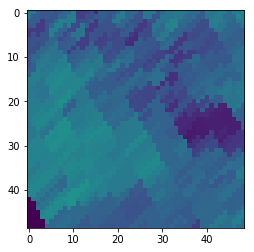

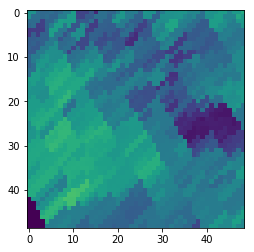

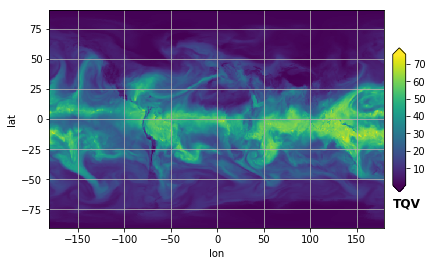

In [76]:
rsurf=rsurf.reshape((NB, XSIZE, YSIZE),order='C')
figure()
imshow(rtoa[1,:,:],vmax=.8,vmin=0)
figure()
imshow(rsurf[1,:,:],vmax=.8,vmin=0)
figure()

merra_lut['TQV'].sub()[Idx(12),:,:].plot()